<a href="https://colab.research.google.com/github/nuha18/SAM-AI-Tech-Internship/blob/main/Task_2(AnalysisOfUnemp).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
#plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [ ]:
df = pd.read_csv('/content/Unemployment in India.csv')
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [ ]:
print(df.shape)

(768, 7)


In [ ]:
print(df.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')>


In [ ]:
print(df.dtypes)

Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [ ]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [ ]:
print(df.info)

<bound method DataFrame.info of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-05-2019    Monthly                              3.65   
1    Andhra Pradesh   30-06-2019    Monthly                              3.05   
2    Andhra Pradesh   31-07-2019    Monthly                              3.75   
3    Andhra Pradesh   31-08-2019    Monthly                              3.32   
4    Andhra Pradesh   30-09-2019    Monthly                              5.17   
..              ...          ...        ...                               ...   
763             NaN          NaN        NaN                               NaN   
764             NaN          NaN        NaN                               NaN   
765             NaN          NaN        NaN                               NaN   
766             NaN          NaN        NaN                               NaN   
767             NaN          NaN        NaN                               NaN

In [ ]:
print(df.describe())

       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                                  72.570000  


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation',
    'Region': 'State'
}, inplace=True)
print(df.head())

            State       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly               3.32  12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly               5.17  12256762.0   

   Labour_Participation Area_Type  Month    Year Month_Name  
0                 43.24     Rural    5.0  2019.0        May  
1                 42.05     Rural    6.0  2019.0        Jun  
2                 43.50     Rural    7.0  2019.0        Jul  
3                 43.97     Rural    8.0  2019.0        Aug  
4                 44.68     Rural    9.0  2019.0        Sep  


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%b')

In [ ]:
df.dropna(subset=['Unemployment_Rate'], inplace=True)
print("\nCleaned Data:")
print(df.head())

print("\nDate range:", df['Date'].min(), "to", df['Date'].max())


Cleaned Data:
            State       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly               3.32  12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly               5.17  12256762.0   

   Labour_Participation Area_Type  Month    Year Month_Name  
0                 43.24     Rural    5.0  2019.0        May  
1                 42.05     Rural    6.0  2019.0        Jun  
2                 43.50     Rural    7.0  2019.0        Jul  
3                 43.97     Rural    8.0  2019.0        Aug  
4                 44.68     Rural    9.0  2019.0        Sep  

Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00


In [ ]:
print(df.isnull().sum())

State                   0
Date                    0
Frequency               0
Unemployment_Rate       0
Employed                0
Labour_Participation    0
Area_Type               0
Month                   0
Year                    0
Month_Name              0
dtype: int64


In [ ]:
# Group by date → get average unemployment rate across all states
national = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

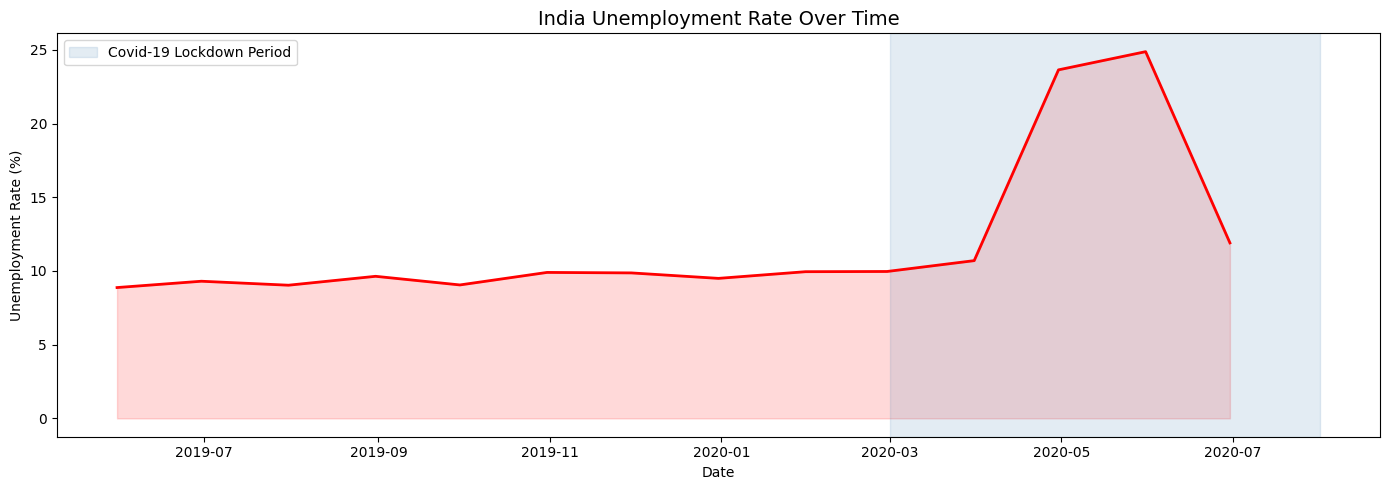

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(national['Date'], national['Unemployment_Rate'],
         color='red', linewidth=2)
plt.fill_between(national['Date'], national['Unemployment_Rate'],
                 alpha=0.15, color='red')
# Highlighting the Covid period
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-01'),
            color='steelblue', alpha=0.15, label='Covid-19 Lockdown Period')
plt.title('India Unemployment Rate Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

**COVID-19 Impact Analysis**

In [ ]:
 #Before, during, and after lockdown comparison
pre_covid  = df[df['Date'] < '2020-03-01']['Unemployment_Rate'].mean()
during_covid = df[(df['Date'] >= '2020-03-01') &
                  (df['Date'] <= '2020-08-31')]['Unemployment_Rate'].mean()
post_covid = df[df['Date'] > '2020-08-31']['Unemployment_Rate'].mean()

print(f"\nPre-Covid average unemployment:    {pre_covid:.2f}%")
print(f"During Covid average unemployment: {during_covid:.2f}%")
print(f"Post-Covid average unemployment:   {post_covid:.2f}%")
print(f"Covid SPIKE: +{during_covid - pre_covid:.2f}%")


Pre-Covid average unemployment:    9.51%
During Covid average unemployment: 17.77%
Post-Covid average unemployment:   nan%
Covid SPIKE: +8.26%


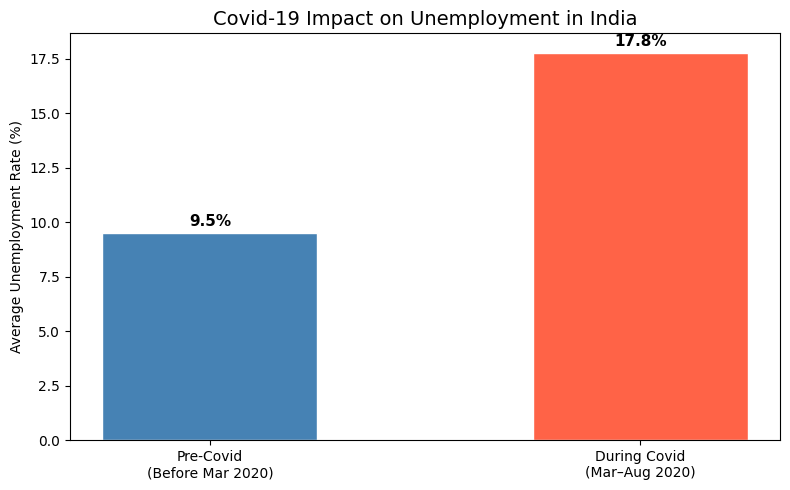

In [ ]:
#BAR GRAPH COMPARISON
periods = ['Pre-Covid\n(Before Mar 2020)',
           'During Covid\n(Mar–Aug 2020)',
           'Post-Covid\n(After Aug 2020)']
values  = [pre_covid, during_covid, post_covid]
colors  = ['steelblue', 'tomato', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(periods, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('Covid-19 Impact on Unemployment in India', fontsize=14)
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

**State Wise Analysis**

In [ ]:
# Average unemployment by state
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)

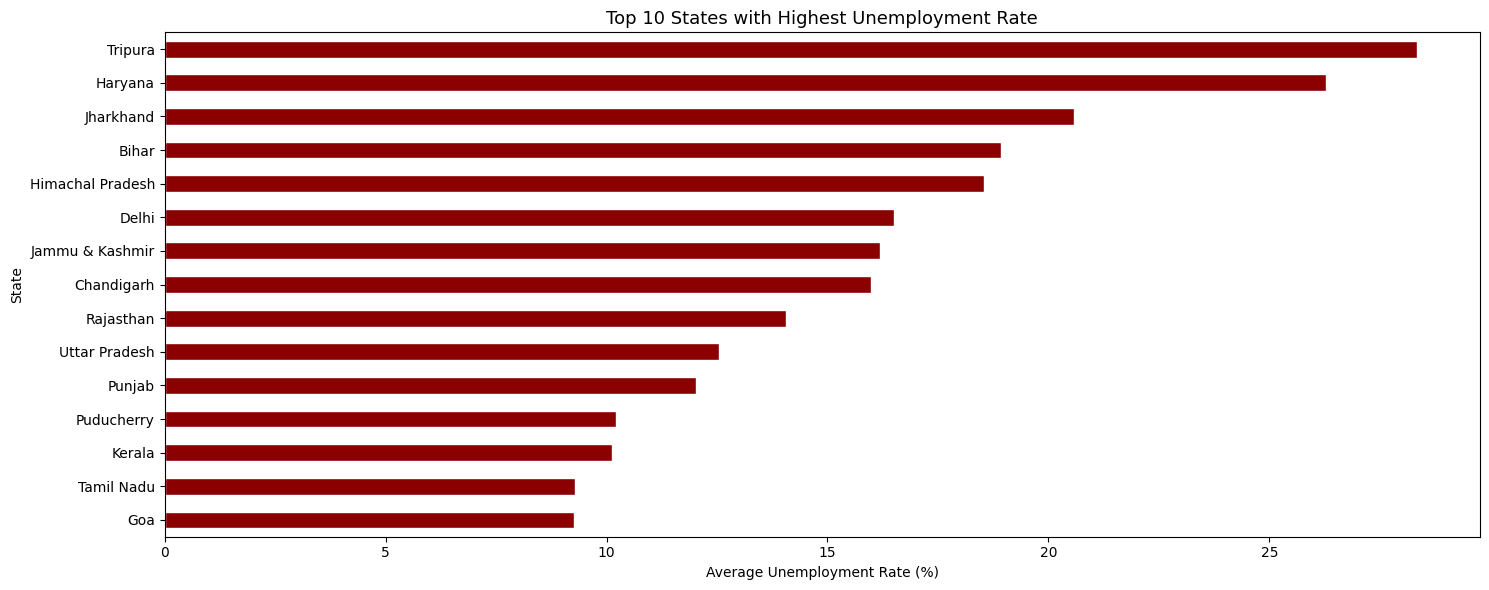

In [ ]:
# Top 15 worst affected states
plt.figure(figsize=(15, 6))
state_avg.head(15).plot(kind='barh', color='darkred', edgecolor='white')
plt.title('Top 10 States with Highest Unemployment Rate', fontsize=13)
plt.xlabel('Average Unemployment Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


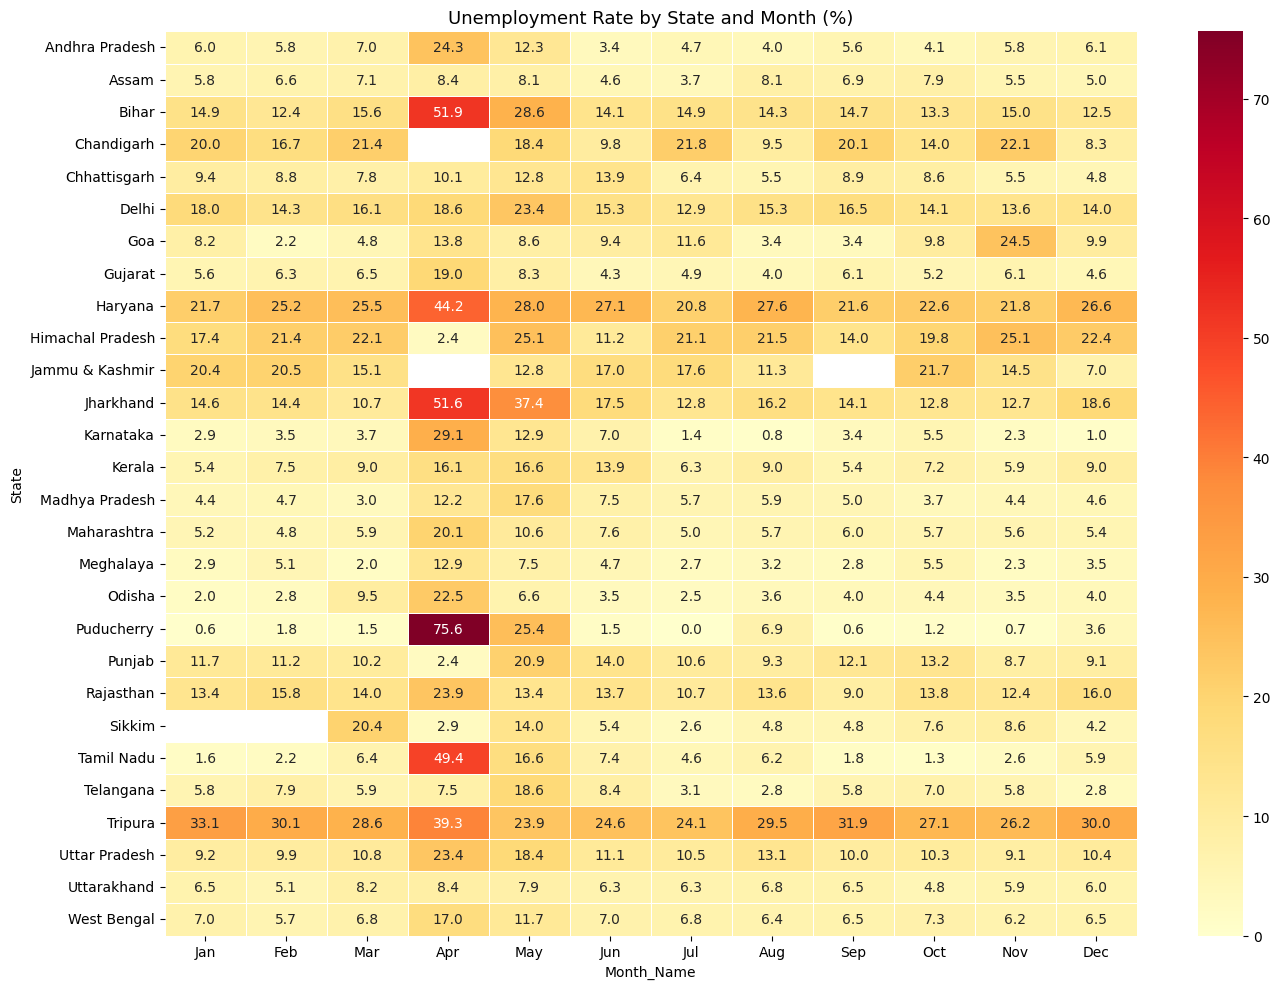

In [ ]:
#HEATMAP FOR CLEAR DISTINCTION ACCORDING TO MONTHS
state_month = df.pivot_table(values='Unemployment_Rate',
                              index='State',
                              columns='Month_Name',
                              aggfunc='mean')

# Reorder months Jan → Dec
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
state_month = state_month.reindex(columns=month_order)

plt.figure(figsize=(14, 10))
sns.heatmap(state_month, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Unemployment Rate by State and Month (%)', fontsize=13)
plt.tight_layout()
plt.show()

**SEASONAL PATTERNS**

In [ ]:
monthly_avg = df.groupby('Month')['Unemployment_Rate'].mean()

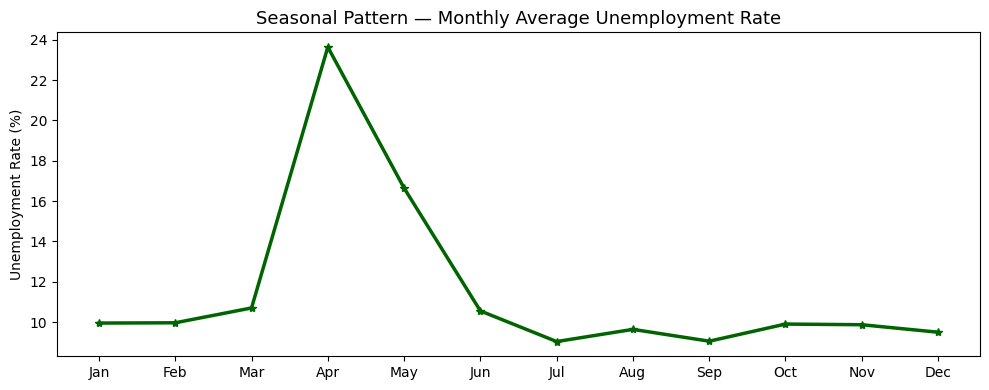

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(monthly_avg.index, monthly_avg.values,
         marker='*', color='darkgreen', linewidth=2.5)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Seasonal Pattern — Monthly Average Unemployment Rate', fontsize=13)
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

**Rural VS Urban**

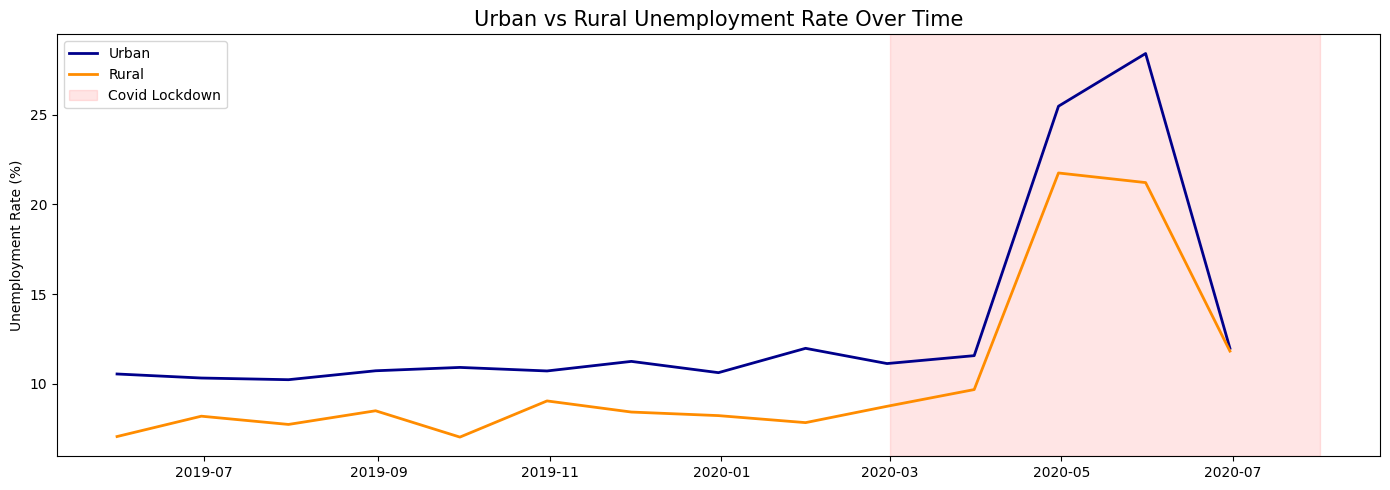

In [ ]:
if 'Area_Type' in df.columns:
    area_trend = df.groupby(['Date', 'Area_Type'])['Unemployment_Rate'].mean().reset_index()
    plt.figure(figsize=(14, 5))
    for area, color in [('Urban', 'darkblue'), ('Rural', 'darkorange')]:
        subset = area_trend[area_trend['Area_Type'] == area]
        plt.plot(subset['Date'], subset['Unemployment_Rate'],
                 label=area, color=color, linewidth=2)

    plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-01'),
                color='red', alpha=0.1, label='Covid Lockdown')
    plt.title('Urban vs Rural Unemployment Rate Over Time', fontsize=15)
    plt.ylabel('Unemployment Rate (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

**FINAL SUMMARY REPORT OF THE ABOVE ANALYSIS**

In [ ]:
print("=" * 50)
print("       UNEMPLOYMENT ANALYSIS — KEY INSIGHTS")
print("=" * 50)
print(f"Period covered:        {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"States analyzed:       {df['State'].nunique()}")
print(f"Overall avg rate:      {df['Unemployment_Rate'].mean():.2f}%")
print(f"Highest ever rate:     {df['Unemployment_Rate'].max():.2f}%")
print(f"Lowest ever rate:      {df['Unemployment_Rate'].min():.2f}%")
print(f"Most affected state:   {state_avg.index[0]} ({state_avg.iloc[0]:.1f}%)")
print(f"Least affected state:  {state_avg.index[-1]} ({state_avg.iloc[-1]:.1f}%)")
print(f"Covid spike:           +{during_covid - pre_covid:.2f}% above pre-Covid levels")
print("=" * 50)

       UNEMPLOYMENT ANALYSIS — KEY INSIGHTS
Period covered:        2019-05-31 to 2020-06-30
States analyzed:       28
Overall avg rate:      11.79%
Highest ever rate:     76.74%
Lowest ever rate:      0.00%
Most affected state:   Tripura (28.4%)
Least affected state:  Meghalaya (4.8%)
Covid spike:           +8.26% above pre-Covid levels
